In [5]:
import os
import torch
import torchaudio
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import datasets
import tarfile
import re
import glob
import shutil

from sklearn.model_selection import train_test_split
from scipy.signal import welch
from tqdm.auto import tqdm

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Run Model on: {DEVICE}")

Run Model on: cuda


# Prepare Data for EDA

In [111]:
tarfile_path = r"dataset\urban-frdr\audio_2022_chunk_121.tar.gz"
csv_frdr = r"dataset\urban-frdr\inspections_2022.csv"
csv_zenodo = r"dataset\zenodo\state_labels.csv"
frdr_audiofolder_path = r"dataset/urban-frdr/audio_2022_all_chunk"
zenodo_audiofolder_path = r"dataset\zenodo"

### Extract chuck

In [103]:
output_folder = "dataset/urban-frdr/audio_2022_chunk_121"
with tarfile.open(tarfile_path,"r:gz") as tar:
    tar.extractall(path=output_folder)

C:\Users\USER\AppData\Local\Temp\ipykernel_8348\2844830984.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=output_folder)


### checking status

In [112]:
df_frdr = pd.read_csv(csv_frdr)
target= df_frdr[(df_frdr['Queen status'] == 'queenless') | (df_frdr['Category'] == 'varroa')]
print(target[['Date', 'Tag number', 'Category', 'Queen status']])

                                 Date  Tag number        Category Queen status
17   2022-08-24 20:30:15.427454+00:00        3627          varroa   queenright
31   2022-07-11 20:23:05.641387+00:00        3692     hive status    queenless
32   2022-07-11 20:23:05.641387+00:00        3692    hive grading    queenless
33   2022-07-11 20:23:05.641387+00:00        3692  frames of bees    queenless
34   2022-07-19 21:32:34.257822+00:00        3692     hive status    queenless
35   2022-07-19 21:32:34.257822+00:00        3692    hive grading    queenless
44   2022-08-24 20:16:33.633384+00:00        3692          varroa   queenright
71   2022-08-24 20:53:05.475343+00:00        3691          varroa   queenright
77   2022-09-30 21:47:53.014515+00:00        3691          varroa   queenright
98   2022-08-24 21:11:39.506501+00:00        3628          varroa   queenright
105  2022-09-30 21:29:31.817886+00:00        3628          varroa   queenright
108  2022-06-02 17:13:07.060900+00:00        3693   

### check status on downloaded chuck

In [117]:
file_list = os.listdir(frdr_audiofolder_path)
print(file_list)

['01-09-2022_00h30_HIVE-3631_Infested.wav', '01-09-2022_02h00_HIVE-3631_Infested.wav', '01-09-2022_02h45_HIVE-3631_Infested.wav', '01-09-2022_06h30_HIVE-6_Infested.wav', '01-09-2022_07h15_HIVE-3631_Infested.wav', '01-09-2022_07h30_HIVE-6_Infested.wav', '01-09-2022_07h45_HIVE-3631_Infested.wav', '01-09-2022_19h15_HIVE-3631_Infested.wav', '01-09-2022_20h30_HIVE-3693_Active.wav', '01-09-2022_20h45_HIVE-3690_Active.wav', '01-09-2022_21h30_HIVE-6_Infested.wav', '01-09-2022_21h45_HIVE-3631_Infested.wav', '01-09-2022_21h45_HIVE-3690_Active.wav', '01-09-2022_21h45_HIVE-3691_Active.wav', '01-09-2022_22h00_HIVE-3628_Active.wav', '02-06-2022_01h15_HIVE-3631_Active.wav', '02-06-2022_01h30_HIVE-6_Queenless.wav', '02-06-2022_01h45_HIVE-3631_Active.wav', '02-06-2022_02h00_HIVE-6_Queenless.wav', '02-06-2022_02h15_HIVE-3631_Active.wav', '02-06-2022_04h30_HIVE-6_Queenless.wav', '02-06-2022_04h45_HIVE-3631_Active.wav', '02-06-2022_06h30_HIVE-6_Queenless.wav', '02-06-2022_06h45_HIVE-3631_Active.wav', '02-

In [119]:
all_files = ['01-09-2022_00h30_HIVE-3631_Infested.wav', '01-09-2022_02h00_HIVE-3631_Infested.wav', '01-09-2022_02h45_HIVE-3631_Infested.wav', '01-09-2022_06h30_HIVE-6_Infested.wav', '01-09-2022_07h15_HIVE-3631_Infested.wav', '01-09-2022_07h30_HIVE-6_Infested.wav', '01-09-2022_07h45_HIVE-3631_Infested.wav', '01-09-2022_19h15_HIVE-3631_Infested.wav', '01-09-2022_20h30_HIVE-3693_Active.wav', '01-09-2022_20h45_HIVE-3690_Active.wav', '01-09-2022_21h30_HIVE-6_Infested.wav', '01-09-2022_21h45_HIVE-3631_Infested.wav', '01-09-2022_21h45_HIVE-3690_Active.wav', '01-09-2022_21h45_HIVE-3691_Active.wav', '01-09-2022_22h00_HIVE-3628_Active.wav', '02-06-2022_01h15_HIVE-3631_Active.wav', '02-06-2022_01h30_HIVE-6_Queenless.wav', '02-06-2022_01h45_HIVE-3631_Active.wav', '02-06-2022_02h00_HIVE-6_Queenless.wav', '02-06-2022_02h15_HIVE-3631_Active.wav', '02-06-2022_04h30_HIVE-6_Queenless.wav', '02-06-2022_04h45_HIVE-3631_Active.wav', '02-06-2022_06h30_HIVE-6_Queenless.wav', '02-06-2022_06h45_HIVE-3631_Active.wav', '02-06-2022_07h00_HIVE-6_Queenless.wav', '02-06-2022_07h15_HIVE-3631_Active.wav', '02-06-2022_10h00_HIVE-3693_Queenless.wav', '02-06-2022_10h00_HIVE-6_Queenless.wav', '02-06-2022_10h15_HIVE-3631_Active.wav', '02-06-2022_10h15_HIVE-3690_Queenless.wav', '02-06-2022_12h00_HIVE-3628_Active.wav', '02-06-2022_12h00_HIVE-6_Queenless.wav', '02-06-2022_12h15_HIVE-3631_Active.wav', '02-06-2022_12h15_HIVE-3690_Queenless.wav', '02-06-2022_12h30_HIVE-6_Queenless.wav', '02-06-2022_12h45_HIVE-3631_Active.wav', '02-06-2022_12h45_HIVE-3690_Queenless.wav', '02-06-2022_13h00_HIVE-6_Queenless.wav', '02-06-2022_13h15_HIVE-3631_Active.wav', '02-06-2022_13h15_HIVE-3690_Queenless.wav', '02-06-2022_14h30_HIVE-3693_Queenless.wav', '02-06-2022_15h00_HIVE-3628_Active.wav', '02-06-2022_15h00_HIVE-6_Queenless.wav', '02-06-2022_15h45_HIVE-3690_Queenless.wav', '02-06-2022_16h15_HIVE-3690_Queenless.wav', '02-06-2022_16h15_HIVE-3692_Active.wav', '02-06-2022_16h30_HIVE-3627_Active.wav', '02-06-2022_16h30_HIVE-3693_Queenless.wav', '04-07-2022_17h00_HIVE-3690_Active.wav', '04-07-2022_21h15_HIVE-3640_Active.wav', '04-08-2022_06h45_HIVE-3691_Active.wav', '04-08-2022_09h00_HIVE-3628_Active.wav', '07-06-2022_00h00_HIVE-3693_Queenless.wav', '07-06-2022_00h30_HIVE-3693_Queenless.wav', '07-06-2022_02h00_HIVE-3693_Queenless.wav', '07-06-2022_02h15_HIVE-3690_Queenless.wav', '07-06-2022_04h00_HIVE-3693_Queenless.wav', '07-06-2022_10h30_HIVE-3693_Queenless.wav', '07-06-2022_12h15_HIVE-3690_Queenless.wav', '07-06-2022_14h15_HIVE-3690_Queenless.wav', '07-06-2022_14h30_HIVE-3693_Queenless.wav', '07-06-2022_14h45_HIVE-3690_Queenless.wav', '07-06-2022_19h00_HIVE-3693_Queenless.wav', '07-06-2022_19h15_HIVE-3690_Queenless.wav', '07-06-2022_20h00_HIVE-3693_Queenless.wav', '07-06-2022_20h15_HIVE-3690_Queenless.wav', '07-09-2022_00h00_HIVE-3690_Active.wav', '07-09-2022_00h15_HIVE-3693_Active.wav', '07-09-2022_00h15_HIVE-6_Active.wav', '07-09-2022_00h45_HIVE-6_Active.wav', '07-09-2022_01h00_HIVE-3631_Active.wav', '07-09-2022_01h00_HIVE-3690_Active.wav', '07-09-2022_01h15_HIVE-3693_Active.wav', '07-09-2022_09h45_HIVE-6_Active.wav', '07-09-2022_16h30_HIVE-3631_Active.wav', '07-09-2022_17h15_HIVE-6_Active.wav', '07-09-2022_17h30_HIVE-3631_Active.wav', '07-09-2022_23h30_HIVE-3631_Active.wav', '07-09-2022_23h45_HIVE-6_Active.wav', '11-07-2022_00h30_HIVE-3690_Active.wav', '21-09-2022_03h15_HIVE-6_Active.wav', '21-09-2022_03h30_HIVE-3631_Active.wav', '21-09-2022_03h30_HIVE-3691_Active.wav', '21-09-2022_04h00_HIVE-3691_Active.wav', '21-09-2022_07h30_HIVE-3691_Active.wav', '21-09-2022_07h45_HIVE-6_Active.wav', '21-09-2022_08h15_HIVE-6_Active.wav', '21-09-2022_08h30_HIVE-3631_Active.wav', '21-09-2022_08h30_HIVE-3691_Active.wav', '21-09-2022_18h15_HIVE-3628_Active.wav', '21-09-2022_18h30_HIVE-3631_Active.wav', '24-08-2022_00h15_HIVE-6_Active.wav', '24-08-2022_00h30_HIVE-3628_Infested.wav', '24-08-2022_00h30_HIVE-3631_Active.wav', '24-08-2022_00h45_HIVE-3691_Infested.wav', '24-08-2022_00h45_HIVE-6_Active.wav', '24-08-2022_03h30_HIVE-3628_Infested.wav', '24-08-2022_04h00_HIVE-3628_Infested.wav', '24-08-2022_04h00_HIVE-6_Active.wav', '24-08-2022_07h15_HIVE-3631_Active.wav', '24-08-2022_07h30_HIVE-6_Active.wav', '24-08-2022_09h30_HIVE-3628_Infested.wav', '24-08-2022_12h00_HIVE-3628_Infested.wav', '24-08-2022_12h30_HIVE-3628_Infested.wav', '24-08-2022_12h30_HIVE-6_Active.wav', '24-08-2022_12h45_HIVE-3631_Active.wav', '24-08-2022_20h00_HIVE-3628_Infested.wav', '24-08-2022_20h00_HIVE-3693_Infested.wav', '24-08-2022_20h00_HIVE-6_Active.wav', '24-08-2022_20h15_HIVE-3631_Active.wav', '24-08-2022_23h30_HIVE-3693_Infested.wav', '27-06-2022_03h15_HIVE-3640_Active.wav', '27-06-2022_15h45_HIVE-3640_Active.wav', '27-06-2022_21h15_HIVE-3640_Active.wav', '29-09-2022_01h00_HIVE-3690_Active.wav', '29-09-2022_01h15_HIVE-6_Active.wav', '29-09-2022_02h30_HIVE-3690_Active.wav', '29-09-2022_02h45_HIVE-6_Active.wav', '29-09-2022_03h00_HIVE-3690_Active.wav', '29-09-2022_04h00_HIVE-3640_Active.wav', '29-09-2022_04h00_HIVE-3690_Active.wav', '29-09-2022_18h15_HIVE-3640_Active.wav', '29-09-2022_22h30_HIVE-3631_Active.wav', '29-09-2022_22h45_HIVE-3640_Active.wav', '29-09-2022_22h45_HIVE-6_Active.wav', '30-09-2022_01h00_HIVE-3631_Infested.wav', '30-09-2022_01h00_HIVE-3690_Infested.wav', '30-09-2022_01h15_HIVE-3640_Infested.wav', '30-09-2022_01h15_HIVE-3693_Infested.wav', '30-09-2022_02h15_HIVE-3640_Infested.wav', '30-09-2022_03h15_HIVE-3640_Infested.wav', '30-09-2022_06h45_HIVE-3631_Infested.wav', '30-09-2022_06h45_HIVE-3640_Infested.wav', '30-09-2022_06h45_HIVE-3693_Infested.wav', '30-09-2022_07h00_HIVE-3690_Infested.wav', '30-09-2022_12h30_HIVE-6_Infested.wav', '30-09-2022_12h45_HIVE-3640_Infested.wav', '30-09-2022_15h15_HIVE-3631_Infested.wav', '30-09-2022_15h15_HIVE-3693_Infested.wav', '30-09-2022_15h30_HIVE-3690_Infested.wav', '30-09-2022_15h45_HIVE-3693_Infested.wav', '30-09-2022_16h00_HIVE-3690_Infested.wav', '30-09-2022_16h00_HIVE-6_Infested.wav', '30-09-2022_17h00_HIVE-3690_Infested.wav', '30-09-2022_17h00_HIVE-3691_Infested.wav', '30-09-2022_17h00_HIVE-6_Infested.wav', '30-09-2022_17h15_HIVE-3631_Infested.wav', '30-09-2022_17h15_HIVE-3640_Infested.wav', '30-09-2022_18h30_HIVE-6_Infested.wav', '30-09-2022_20h00_HIVE-3690_Infested.wav', '30-09-2022_20h00_HIVE-6_Infested.wav', '30-09-2022_20h15_HIVE-3631_Infested.wav', '30-09-2022_20h15_HIVE-3693_Infested.wav', '30-09-2022_20h30_HIVE-3640_Infested.wav', '30-09-2022_20h30_HIVE-6_Infested.wav', '30-09-2022_21h30_HIVE-3691_Infested.wav', '30-09-2022_21h45_HIVE-3631_Infested.wav', '30-09-2022_21h45_HIVE-3693_Infested.wav', '30-09-2022_22h00_HIVE-3690_Infested.wav', '30-09-2022_22h00_HIVE-6_Infested.wav', '30-09-2022_22h15_HIVE-3631_Infested.wav', '30-09-2022_22h15_HIVE-3693_Infested.wav']
extract_list = []
for file_path in all_files:
    if file_path.endswith('.wav'):
        file_name = file_path.split('/')[-1]
        parts = file_name.split('_')
        date = parts[0]
        hive_part = parts[2]
        hive_id = hive_part.split('-')[1].split('.')[0]
        for_merge = pd.to_datetime(date, format='%d-%m-%Y').strftime('%Y-%m-%d')
        extract_list.append({
            'Filename': file_name,
            'Date': for_merge,
            'Tag number': int(hive_id)
        })

df_audio = pd.DataFrame(extract_list)
df_audio['Tag number'] = df_audio['Tag number'].astype(int)

df_frdr['Tag number'] = df_frdr['Tag number'].astype(int)
df_frdr['Date'] = pd.to_datetime(df_frdr['Date']).dt.strftime('%Y-%m-%d')

# ทำไว้ใช้กันแถว infested ซ้ำกับ active
df_frdr_sorted = df_frdr.sort_values(by=['Date', 'Tag number', 'Category'], ascending=[True, True, False])
df_frdr_clean = df_frdr_sorted.drop_duplicates(subset=['Date', 'Tag number'], keep='first')
merge_df = pd.merge(df_audio, df_frdr_clean, on=['Date', 'Tag number'], how='inner')

def check_class(row):
    if row['Category'] == 'varroa':
        return 'Class 2: Infested'
    elif row['Queen status'] == 'queenless':
        return 'Class 1: Queenless'
    elif row['Queen status'] == 'queenright' and row['Is alive'] == 1:
        return 'Class 0: Active'
    else:
        return 'Others / Ignored'
merge_df['target_Class'] = merge_df.apply(check_class, axis=1)

# Check Other / Ignored (deaded bee)
# print(merge_df[merge_df['target_Class'] == 'Others / Ignored'])

for index, row in merge_df.iterrows():
    print(f"{index}. File: {row['Filename']} | {row['target_Class']}")
print(merge_df['target_Class'].value_counts())

0. File: 01-09-2022_00h30_HIVE-3631_Infested.wav | Class 2: Infested
1. File: 01-09-2022_02h00_HIVE-3631_Infested.wav | Class 2: Infested
2. File: 01-09-2022_02h45_HIVE-3631_Infested.wav | Class 2: Infested
3. File: 01-09-2022_06h30_HIVE-6_Infested.wav | Class 2: Infested
4. File: 01-09-2022_07h15_HIVE-3631_Infested.wav | Class 2: Infested
5. File: 01-09-2022_07h30_HIVE-6_Infested.wav | Class 2: Infested
6. File: 01-09-2022_07h45_HIVE-3631_Infested.wav | Class 2: Infested
7. File: 01-09-2022_19h15_HIVE-3631_Infested.wav | Class 2: Infested
8. File: 01-09-2022_20h30_HIVE-3693_Active.wav | Class 0: Active
9. File: 01-09-2022_20h45_HIVE-3690_Active.wav | Class 0: Active
10. File: 01-09-2022_21h30_HIVE-6_Infested.wav | Class 2: Infested
11. File: 01-09-2022_21h45_HIVE-3631_Infested.wav | Class 2: Infested
12. File: 01-09-2022_21h45_HIVE-3690_Active.wav | Class 0: Active
13. File: 01-09-2022_21h45_HIVE-3691_Active.wav | Class 0: Active
14. File: 01-09-2022_22h00_HIVE-3628_Active.wav | Class

In [110]:
unmapped_folder_path = os.path.join(os.path.dirname(frdr_audiofolder_path), "unmapped_audio")
if not os.path.exists(unmapped_folder_path):
    os.makedirs(unmapped_folder_path)
frdr_class_map = {}
for index, row in merge_df.iterrows():
    old_name = row['Filename']
    current_class = row['target_Class']
    class_suffix = current_class.split(': ')[1] # ดึงคำ Active, Queenless, Infested ออกมา
    frdr_class_map[old_name] = class_suffix

all_files_in_folder = os.listdir(frdr_audiofolder_path)

rename_count = 0
move_count = 0
for filename in tqdm(all_files_in_folder, total=len(all_files_in_folder)):
    
    if filename.endswith('.wav'):
        old_file_path = os.path.join(frdr_audiofolder_path, filename)
        
        if filename in frdr_class_map:
            class_suffix = frdr_class_map[filename]
            
            name_part, ext_part = os.path.splitext(filename)
            new_filename = f"{name_part}_{class_suffix}{ext_part}"
            new_file_path = os.path.join(frdr_audiofolder_path, new_filename)
            
            if os.path.exists(old_file_path):
                os.rename(old_file_path, new_file_path)
                rename_count += 1
                
        else:
            destination_file_path = os.path.join(unmapped_folder_path, filename)
            
            if os.path.exists(old_file_path):
                shutil.move(old_file_path, destination_file_path) # สั่งย้ายไฟล์ข้ามโฟลเดอร์
                move_count += 1

print(f"Found: {rename_count} Files")

  0%|          | 0/381 [00:00<?, ?it/s]

Found: 24 Files


# Exploratory Data Analysis (EDA)

### Compare noise level (Active)

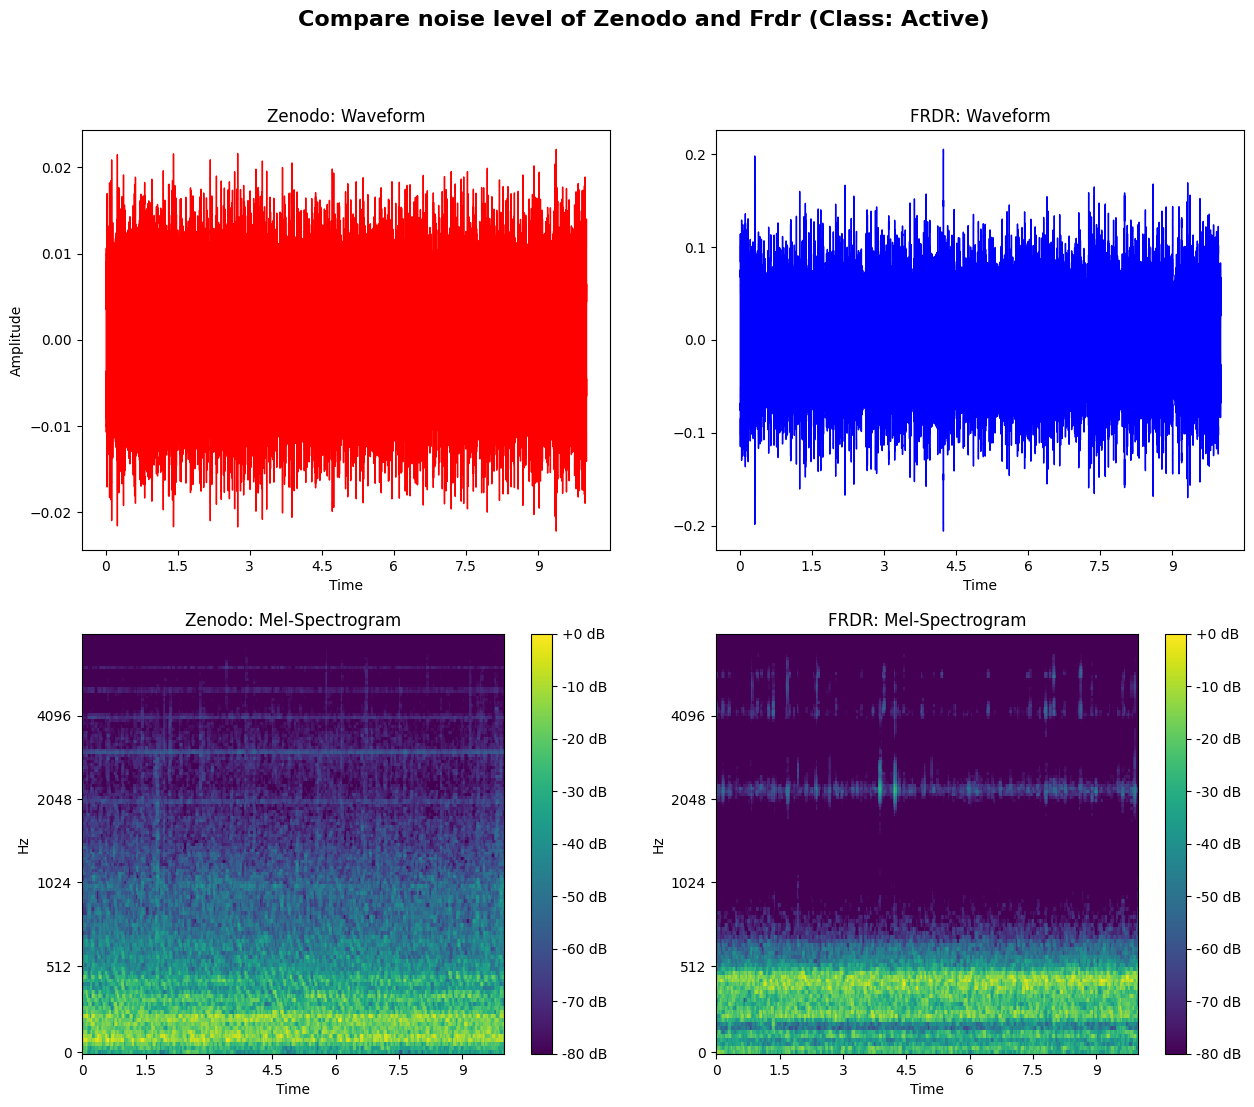

In [99]:
zenodo_active_path = r"dataset\zenodo\Hive1_12_06_2018\Hive1 12_06_2018_QueenBee____00_00_00.wav"
frdr_active_path = r"dataset\urban-frdr\audio_2022_all_chunk\04-08-2022_19h15_HIVE-3690_Active.wav"

sample_rate = 16000
audio_zenodo, sr_z = librosa.load(zenodo_active_path, sr=sample_rate)
audio_frdr, sr_f = librosa.load(frdr_active_path, sr=sample_rate)

duration = 10 #(Sec)
audio_zenodo = audio_zenodo[:sample_rate * duration]
audio_frdr = audio_frdr[:sample_rate * duration]
# print(audio_frdr)

main_plot, sub_plot = plt.subplots(2, 2, figsize=(15, 12), sharex=False)
main_plot.suptitle("Compare noise level of Zenodo and Frdr (Class: Active)", fontsize=16, fontweight='bold')
sub_plot[0, 0].set_title("Zenodo: Waveform")
librosa.display.waveshow(audio_zenodo, sr=sample_rate, ax=sub_plot[0, 0], color='red')
sub_plot[0, 0].set_ylabel("Amplitude")

sub_plot[0, 1].set_title("FRDR: Waveform")
librosa.display.waveshow(audio_frdr, sr=sample_rate, ax=sub_plot[0, 1], color='blue')
#=============================================================
mel_zenodo = librosa.feature.melspectrogram(y=audio_zenodo, sr=sample_rate, n_mels=128)
mel_db_zenodo = librosa.amplitude_to_db(mel_zenodo, ref=np.max)

sub_plot[1, 0].set_title("Zenodo: Mel-Spectrogram")
img1 = librosa.display.specshow(mel_db_zenodo, sr=sample_rate, x_axis='time', y_axis='mel', ax=sub_plot[1, 0], cmap='viridis')
main_plot.colorbar(img1, ax=sub_plot[1,0], format='%+2.0f dB')

mel_frdr = librosa.feature.melspectrogram(y=audio_frdr, sr=sample_rate, n_mels=128)
mel_db_frdr = librosa.amplitude_to_db(mel_frdr, ref=np.max)
sub_plot[1, 1].set_title("FRDR: Mel-Spectrogram")
img2 = librosa.display.specshow(mel_db_frdr, sr=sample_rate, x_axis='time', y_axis='mel', ax=sub_plot[1, 1], cmap='viridis')
main_plot.colorbar(img2, ax=sub_plot[1,1], format='%+2.0f dB')
#=============================================================

In [98]:
frdr_hives = df_audio['Tag number'].unique()
total_frdr_hives = len(frdr_hives)

print(f"Total FRDR Hive: {total_frdr_hives} hives")
print(f"FRDR Name list: {sorted(frdr_hives)}")

Total FRDR Hive: 8 hives
FRDR Name list: [np.int64(6), np.int64(3627), np.int64(3628), np.int64(3631), np.int64(3640), np.int64(3690), np.int64(3691), np.int64(3693)]


## Total hives
- frdr: 8 hives
- zenodo: 2 hives

## Data split